In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os

In [24]:
# Создать директорию для графиков
os.makedirs('kallisto_plots', exist_ok=True)
plt.rcParams['figure.figsize'] = (12, 10)

In [25]:
ground_truth_percentages = [
    [0.901, 0, 0.128, 98.132, 0, 0, 0.450, 0, 0, 0, 0.386],
    [3.225, 0, 0.444, 91.657, 0, 0, 2.780, 0, 0, 0, 1.890],
    [8.211, 0.182, 0.669, 86.678, 0.121, 0, 3.102, 0, 0, 0, 1.034],
    [5.664, 0.129, 0.284, 89.730, 0.078, 0.360, 2.224, 0, 0, 0, 1.526],
    [5.454, 0.122, 0.531, 90.357, 0.265, 0.102, 2.226, 0, 0, 0, 0.939],
    [9.690, 0.169, 0.120, 84.001, 0.338, 0.072, 3.528, 0, 0.024, 0, 2.054],
    [12.816, 0.394, 0.037, 78.701, 0.319, 0.037, 6.173, 0, 0.075, 0, 1.444],
    [13.509, 0.305, 0.051, 78.666, 0.368, 0.089, 6.042, 0, 0.051, 0, 0.915],
    [20.555, 0.462, 0.060, 68.716, 0.207, 0.146, 7.891, 0, 0.036, 0, 1.924],
    [28.074, 0.752, 0.014, 60.096, 0.184, 0.170, 8.875, 0, 0.156, 0, 1.675],
    [39.221, 0.848, 0.066, 46.540, 0.613, 0.379, 10.767, 0.011, 0.100, 0, 1.450],
    [43.730, 0.879, 0.017, 42.697, 0.469, 0.896, 10.081, 0.025, 0.093, 0.008, 1.101],
    [52.638, 0.966, 0.041, 30.400, 0.575, 1.274, 12.986, 0.041, 0.233, 0.006, 0.836],
    [59.192, 0.986, 0.060, 23.009, 0.551, 1.942, 13.444, 0.090, 0.125, 0.005, 0.595],
    [63.386, 0.962, 0.076, 16.452, 0.511, 3.007, 15.055, 0.056, 0.132, 0.004, 0.354],
    [68.156, 0.941, 0.126, 11.588, 0.443, 4.464, 13.626, 0.097, 0.203, 0.003, 0.349],
    [71.272, 0.984, 0.205, 8.356, 0.430, 5.516, 12.728, 0.171, 0.191, 0.011, 0.132],
    [71.693, 0.935, 0.491, 6.260, 0.365, 6.729, 12.998, 0.193, 0.238, 0, 0.092],
    [72.674, 0.830, 1.133, 4.876, 0.385, 7.625, 11.917, 0.192, 0.328, 0, 0.037],
    [73.363, 0.914, 1.560, 3.653, 0.350, 9.314, 10.406, 0.117, 0.280, 0.003, 0.031],
    [73.655, 0.907, 2.258, 2.952, 0.285, 10.116, 9.386, 0.086, 0.325, 0.011, 0.014],
    [72.514, 0.733, 3.193, 2.273, 0.176, 11.428, 9.279, 0.038, 0.343, 0.014, 0.004],
    [70.802, 0.851, 5.351, 1.491, 0.157, 12.237, 8.661, 0.018, 0.422, 0.006, 0],
    [66.962, 0.536, 10.030, 1.309, 0.114, 13.353, 7.226, 0.017, 0.430, 0.008, 0.008],
    [58.024, 0.331, 19.942, 0.741, 0.199, 13.704, 6.691, 0.011, 0.331, 0, 0.022],
    [49.989, 0.220, 32.039, 0.490, 0.110, 12.037, 4.652, 0, 0.460, 0, 0],
    [39.350, 0.120, 46.363, 0.290, 0.040, 10.328, 3.085, 0.010, 0.410, 0, 0],
    [24.301, 0.050, 64.570, 0.192, 0.033, 8.595, 1.819, 0, 0.419, 0.017, 0],
    [15.025, 0.062, 77.618, 0.062, 0.013, 5.887, 1.099, 0, 0.229, 0, 0],
    [7.749, 0.028, 88.004, 0.028, 0, 3.407, 0.532, 0, 0.247, 0, 0],
    [3.907, 0.014, 93.662, 0.008, 0.002, 2.032, 0.211, 0, 0.160, 0, 0],
    [1.931, 0.014, 96.704, 0.013, 0, 1.166, 0.076, 0, 0.093, 0, 0],
    [1.051, 0.001, 98.147, 0.006, 0, 0.697, 0.043, 0, 0.052, 0, 0],
    [0.480, 0.002, 98.651, 0, 0, 0.490, 0.321, 0, 0.053, 0, 0],
    [0.254, 0.001, 99.457, 0, 0, 0.246, 0.014, 0, 0.025, 0, 0],
    [0.142, 0.001, 99.533, 0.119, 0, 0.162, 0.014, 0.001, 0.023, 0, 0],
    [0.065, 0.001, 99.811, 0.002, 0, 0.110, 0.002, 0.001, 0.004, 0, 0],
    [0.050, 0.001, 99.894, 0.001, 0, 0.042, 0.002, 0, 0.006, 0, 0],
    [0.029, 0, 99.935, 0.001, 0, 0.028, 0.002, 0, 0.002, 0, 0],
    [0.054, 0, 99.780, 0.119, 0, 0.039, 0.005, 0, 0, 0, 0],
    [0.005, 0, 99.984, 0, 0, 0.010, 0, 0, 0, 0, 0],
    [0.008, 0, 99.976, 0, 0, 0.015, 0, 0, 0, 0, 0]
]

In [26]:
# Названия колонок (порядок важен!)
lineages = ['Alpha', 'Beta', 'Delta', 'Epsilon', 'Eta', 'Gamma', 'Iota', 'Kappa', 'Lambda', 'Theta', 'Zeta']

In [27]:
# Проверка: сумма процентов должна быть ~100% для каждого сэмпла
print("Проверка Ground Truth - сумма процентов по сэмплам:")
row_sums = gt_df[lineages].sum(axis=1)
print(f"Min: {row_sums.min():.2f}%, Max: {row_sums.max():.2f}%, Mean: {row_sums.mean():.2f}%")

Проверка Ground Truth - сумма процентов по сэмплам:
Min: 99.99%, Max: 100.00%, Mean: 100.00%


In [28]:
# Freyja Results - загрузить файл
freyja_df = pd.read_csv('results/viorel_dataset_FREYJA/plots/results_table_freyja.csv')
freyja_df

,Sample,AY.1,AY.118,AY.4.3,AY.91,B.1.1.7,B.1.351,B.1.429,B.1.525,B.1.526,...,C.37.1,P.1,P.1.1,P.1.10,P.1.11,P.1.12,P.1.16,P.1.4,P.1.7,P.2
0,18,0.000,0.000,0.000,0.000,72.129,0.549,5.866,0.193,12.938,...,0.128,0.000,0.000,5.934,0.000,0.000,0.000,0.000,0.506,0.000
1,35,0.000,99.126,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,33,0.000,98.217,0.000,0.000,0.549,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.306,0.000,0.000
3,39,0.000,99.346,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,42,0.000,99.373,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,15,0.000,0.000,0.000,0.000,63.807,0.519,16.528,0.263,15.035,...,0.000,0.000,0.000,2.299,0.000,0.000,0.000,0.000,0.000,0.183
6,1,0.000,0.000,0.000,0.000,0.416,0.000,98.664,0.000,0.238,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.170
7,11,0.000,0.000,0.000,0.000,39.611,0.447,47.139,0.308,10.608,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.130,0.000,0.979
8,32,0.000,96.774,0.000,0.000,1.353,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.390,0.000,0.189,0.000
9,8,0.000,0.000,0.000,0.000,13.431,0.165,79.156,0.204,5.820,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.515


In [29]:
# ИСПРАВЛЕНИЕ: Sample в Freyja это просто числа (1, 2, 3... 42)
# Нужно преобразовать в S1, S2, S3...
freyja_df['Sample'] = 'S' + freyja_df['Sample'].astype(str)
freyja_df[['Sample']].head(10)

,Sample
0,S18
1,S35
2,S33
3,S39
4,S42
5,S15
6,S1
7,S11
8,S32
9,S8


In [30]:
# Проверка суммы процентов в Freyja
freyja_numeric_cols = [col for col in freyja_df.columns if col != 'Sample']
freyja_sums = freyja_df[freyja_numeric_cols].sum(axis=1)
print(f"Freyja - сумма процентов: Min: {freyja_sums.min():.2f}%, Max: {freyja_sums.max():.2f}%, Mean: {freyja_sums.mean():.2f}%")

Freyja - сумма процентов: Min: 98.37%, Max: 99.49%, Mean: 98.95%


In [31]:
# Ground Truth в длинный формат
gt_long = gt_df.melt(
    id_vars=['Sample'], 
    value_vars=lineages,
    var_name='Lineage', 
    value_name='True_Abundance'
)

In [32]:
# Маппинг Pango lineages -> WHO names
pango_to_who = {
    # Alpha (B.1.1.7)
    'B.1.1.7': 'Alpha',
    # Beta (B.1.351)
    'B.1.351': 'Beta',
    # Gamma (P.1 and sublineages)
    'P.1': 'Gamma', 'P.1.1': 'Gamma', 'P.1.4': 'Gamma', 'P.1.7': 'Gamma',
    'P.1.10': 'Gamma', 'P.1.11': 'Gamma', 'P.1.12': 'Gamma', 'P.1.16': 'Gamma',
    # Delta (B.1.617.2 and AY sublineages)
    'B.1.617.2': 'Delta', 'AY.1': 'Delta', 'AY.4.3': 'Delta', 
    'AY.91': 'Delta', 'AY.118': 'Delta',
    # Epsilon (B.1.427/B.1.429)
    'B.1.427': 'Epsilon', 'B.1.429': 'Epsilon',
    # Eta (B.1.525)
    'B.1.525': 'Eta',
    # Iota (B.1.526)
    'B.1.526': 'Iota',
    # Kappa (B.1.617.1)
    'B.1.617.1': 'Kappa',
    # Lambda (C.37)
    'C.37': 'Lambda', 'C.37.1': 'Lambda',
    # Theta (P.3)
    'P.3': 'Theta',
    # Zeta (P.2)
    'P.2': 'Zeta',
    # Другие
    'B.1.567': 'Other',
    'B.1.595': 'Other',
    'B.1.595.4': 'Other',
}

In [33]:
# Получить список колонок Freyja (все кроме Sample)
freyja_lineage_cols = [col for col in freyja_df.columns if col != 'Sample']
freyja_lineage_cols

['AY.1',
 'AY.118',
 'AY.4.3',
 'AY.91',
 'B.1.1.7',
 'B.1.351',
 'B.1.429',
 'B.1.525',
 'B.1.526',
 'B.1.567',
 'B.1.595',
 'B.1.595.4',
 'B.1.617.1',
 'B.1.617.2',
 'C.37.1',
 'P.1',
 'P.1.1',
 'P.1.10',
 'P.1.11',
 'P.1.12',
 'P.1.16',
 'P.1.4',
 'P.1.7',
 'P.2']

In [34]:
# Агрегировать Freyja результаты по WHO классификации
freyja_long = freyja_df.melt(
    id_vars=['Sample'], 
    value_vars=freyja_lineage_cols, 
    var_name='Pango', 
    value_name='Predicted_Abundance'
)

In [35]:
# Добавить WHO классификацию
freyja_long['Lineage'] = freyja_long['Pango'].map(pango_to_who)
freyja_long.head(20)

,Sample,Pango,Predicted_Abundance,Lineage
0,S18,AY.1,0.00,Delta
1,S35,AY.1,0.00,Delta
2,S33,AY.1,0.00,Delta
3,S39,AY.1,0.00,Delta
4,S42,AY.1,0.00,Delta
5,S15,AY.1,0.00,Delta
6,S1,AY.1,0.00,Delta
7,S11,AY.1,0.00,Delta
8,S32,AY.1,0.00,Delta
9,S8,AY.1,0.00,Delta


In [36]:
# Удалить неизвестные линии и агрегировать
# freyja_long = freyja_long[freyja_long['Lineage'].notna()]
# freyja_long = freyja_long[freyja_long['Lineage'] != 'Other']

In [ ]:
# Агрегировать по Sample и WHO Lineage
freyja_aggregated = freyja_long.groupby(['Sample', 'Lineage'])['Predicted_Abundance'].sum().reset_index()

In [38]:
print("Проверка агрегированных Freyja результатов для S1:")
print(freyja_aggregated[freyja_aggregated['Sample'] == 'S1'])

Проверка агрегированных Freyja результатов для S1:
   Sample  Lineage  Predicted_Abundance
0      S1    Alpha                0.416
1      S1     Beta                0.000
2      S1    Delta                0.000
3      S1  Epsilon               98.664
4      S1      Eta                0.000
5      S1    Gamma                0.000
6      S1     Iota                0.238
7      S1    Kappa                0.000
8      S1   Lambda                0.000
9      S1    Other                0.000
10     S1     Zeta                0.170


In [39]:
# Объединить данные
comparison_df = pd.merge(gt_long, freyja_aggregated, 
                         on=['Sample', 'Lineage'], how='left')
comparison_df['Predicted_Abundance'].fillna(0, inplace=True)

In [40]:
print("Проверка объединенных данных для S1:")
print(comparison_df[comparison_df['Sample'] == 'S1'].sort_values('True_Abundance', ascending=False))

Проверка объединенных данных для S1:
    Sample  Lineage  True_Abundance  Predicted_Abundance
126     S1  Epsilon          98.132               98.664
0       S1    Alpha           0.901                0.416
252     S1     Iota           0.450                0.238
420     S1     Zeta           0.386                0.170
84      S1    Delta           0.128                0.000
42      S1     Beta           0.000                0.000
168     S1      Eta           0.000                0.000
210     S1    Gamma           0.000                0.000
294     S1    Kappa           0.000                0.000
336     S1   Lambda           0.000                0.000
378     S1    Theta           0.000                0.000


In [41]:
# Вычисление метрик
# Фильтр: убрать строки где оба значения очень малы (шум)
comparison_df_filtered = comparison_df[
    (comparison_df['True_Abundance'] > 0.001) | (comparison_df['Predicted_Abundance'] > 0.001)
].copy()

In [42]:
print(f"Всего сравнений после фильтрации: {len(comparison_df_filtered)}")

Всего сравнений после фильтрации: 344


In [43]:
# Вычислить метрики
mae = mean_absolute_error(comparison_df_filtered['True_Abundance'], 
                          comparison_df_filtered['Predicted_Abundance'])
rmse = np.sqrt(mean_squared_error(comparison_df_filtered['True_Abundance'], 
                                   comparison_df_filtered['Predicted_Abundance']))
r2 = r2_score(comparison_df_filtered['True_Abundance'], 
              comparison_df_filtered['Predicted_Abundance'])

In [44]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(comparison_df_filtered['True_Abundance'], 
                                       comparison_df_filtered['Predicted_Abundance'])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(comparison_df_filtered['True_Abundance'], 
                                          comparison_df_filtered['Predicted_Abundance'])

# Вычислить среднюю относительную ошибку (только для ненулевых true values)
comparison_df_filtered['absolute_error'] = np.abs(
    comparison_df_filtered['Predicted_Abundance'] - comparison_df_filtered['True_Abundance']
)

In [45]:
# Относительная ошибка только где True > 0.001
nonzero_true = comparison_df_filtered[comparison_df_filtered['True_Abundance'] > 0.001].copy()
nonzero_true['relative_error'] = (nonzero_true['absolute_error'] / nonzero_true['True_Abundance']) * 100

mean_relative_error = nonzero_true['relative_error'].mean()
median_relative_error = nonzero_true['relative_error'].median()

In [46]:
# Метрики результатов Freyja
print(f"Dataset: 42 samples with {len(lineages)} WHO lineages")
print(f"Comparison: Ground Truth (%) vs Freyja Predictions (%)")
print("-" * 70)
print(f"Mean Absolute Error (MAE):              {mae:.4f}%")
print(f"Root Mean Squared Error (RMSE):         {rmse:.4f}%")
print(f"R² Score:                               {r2:.4f}")
print(f"Pearson Correlation (r):                {pearson_r:.4f} (p={pearson_p:.2e})")
print(f"Spearman Correlation (ρ):               {spearman_r:.4f} (p={spearman_p:.2e})")
print("-" * 70)
print(f"Mean Relative Error:                    {mean_relative_error:.2f}%")
print(f"Median Relative Error:                  {median_relative_error:.2f}%")
print(f"Total comparisons:                      {len(comparison_df_filtered)}")
print(f"Comparisons with True > 0.1%:           {len(nonzero_true)}")

Dataset: 42 samples with 11 WHO lineages
Comparison: Ground Truth (%) vs Freyja Predictions (%)
----------------------------------------------------------------------
Mean Absolute Error (MAE):              0.6439%
Root Mean Squared Error (RMSE):         3.7705%
R² Score:                               0.9793
Pearson Correlation (r):                0.9899 (p=2.76e-292)
Spearman Correlation (ρ):               0.9528 (p=3.65e-179)
----------------------------------------------------------------------
Mean Relative Error:                    55.36%
Median Relative Error:                  50.29%
Total comparisons:                      344
Comparisons with True > 0.1%:           344


In [47]:
# Метрики по линиям
print("-" * 70)
print(f"{'Lineage':<12} {'n':<6} {'MAE':<10} {'RMSE':<10} {'R²':<10} {'r':<10} {'p-value':<12}")
print("-" * 70)

for lineage in lineages:
    lineage_data = comparison_df_filtered[comparison_df_filtered['Lineage'] == lineage]
    if len(lineage_data) > 2:
        lineage_mae = mean_absolute_error(lineage_data['True_Abundance'], 
                                          lineage_data['Predicted_Abundance'])
        lineage_rmse = np.sqrt(mean_squared_error(lineage_data['True_Abundance'], 
                                                   lineage_data['Predicted_Abundance']))
        lineage_r2 = r2_score(lineage_data['True_Abundance'], 
                             lineage_data['Predicted_Abundance'])
        lineage_pearson, lineage_p = stats.pearsonr(lineage_data['True_Abundance'], 
                                                     lineage_data['Predicted_Abundance'])
        
        print(f"{lineage:<12} {len(lineage_data):<6} {lineage_mae:<10.3f} {lineage_rmse:<10.3f} "
              f"{lineage_r2:<10.3f} {lineage_pearson:<10.3f} {lineage_p:<12.2e}")

print("=" * 70)

----------------------------------------------------------------------
Lineage      n      MAE        RMSE       R²         r          p-value     
----------------------------------------------------------------------
Alpha        42     1.707      6.761      0.945      0.973      3.34e-27    
Beta         31     0.275      0.341      0.176      0.892      1.55e-11    
Delta        42     0.782      2.862      0.996      0.998      8.54e-50    
Epsilon      36     1.791      8.414      0.945      0.976      4.38e-24    
Eta          28     0.163      0.188      -0.120     0.879      7.22e-10    
Gamma        39     0.307      0.435      0.991      0.997      1.93e-42    
Iota         40     0.381      1.242      0.937      0.971      3.46e-25    
Kappa        16     0.066      0.086      -0.861     0.485      5.67e-02    
Lambda       34     0.127      0.149      -0.081     0.895      9.78e-13    
Theta        12     0.008      0.009      -3.523     nan        nan         
Zeta       

/home/nicolaedrabcinski/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


Text(0.03, 0.97, 'R² = 0.979\nMAE = 0.64%\nRMSE = 3.77%\nr = 0.990\np = 2.76e-292\nn = 344')

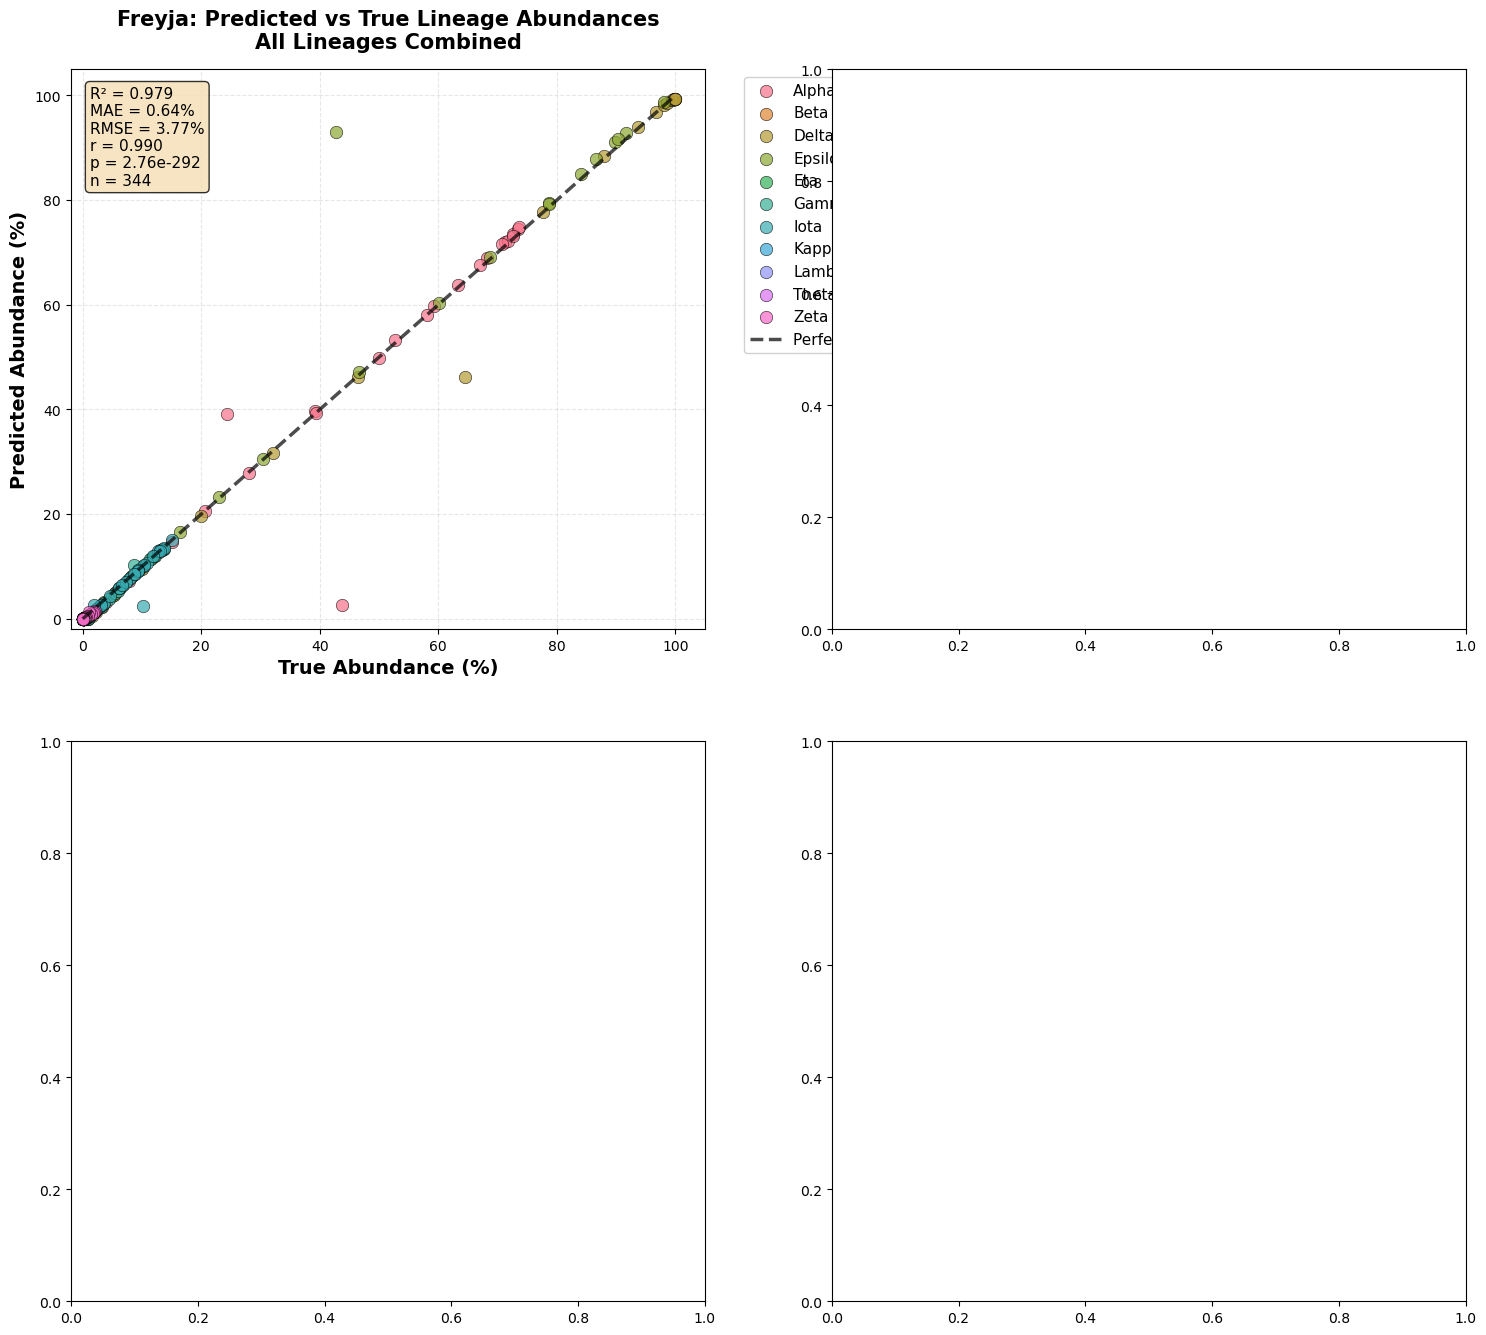

In [48]:
# Создание Scatter plots
# Figure 1: Главный scatter plot с 4 панелями
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Цветовая палитра для линий
colors = sns.color_palette("husl", len(lineages))
lineage_colors = dict(zip(lineages, colors))

# Plot 1: Все данные с цветами по линиям
ax = axes[0, 0]
for lineage in lineages:
    data = comparison_df_filtered[comparison_df_filtered['Lineage'] == lineage]
    if len(data) > 0:
        ax.scatter(data['True_Abundance'], data['Predicted_Abundance'], 
                  alpha=0.7, s=80, label=lineage, color=lineage_colors[lineage],
                  edgecolors='black', linewidth=0.5)

# Диагональная линия (идеальное предсказание)
max_val = max(comparison_df_filtered['True_Abundance'].max(), 
              comparison_df_filtered['Predicted_Abundance'].max())
ax.plot([0, max_val], [0, max_val], 'k--', lw=2.5, label='Perfect prediction', alpha=0.7)

ax.set_xlabel('True Abundance (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Predicted Abundance (%)', fontsize=14, fontweight='bold')
ax.set_title('Freyja: Predicted vs True Lineage Abundances\nAll Lineages Combined', 
            fontsize=15, fontweight='bold', pad=15)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(-2, max_val + 5)
ax.set_ylim(-2, max_val + 5)

# Добавить метрики на график
textstr = (f'R² = {r2:.3f}\n'
          f'MAE = {mae:.2f}%\n'
          f'RMSE = {rmse:.2f}%\n'
          f'r = {pearson_r:.3f}\n'
          f'p = {pearson_p:.2e}\n'
          f'n = {len(comparison_df_filtered)}')
ax.text(0.03, 0.97, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', 
        facecolor='wheat', alpha=0.8, edgecolor='black'))


Проверка агрегированных Freyja результатов для S1:
   Sample  Lineage  Predicted_Abundance
0      S1    Alpha                0.416
1      S1     Beta                0.000
2      S1    Delta                0.000
3      S1  Epsilon               98.664
4      S1      Eta                0.000
5      S1    Gamma                0.000
6      S1     Iota                0.238
7      S1    Kappa                0.000
8      S1   Lambda                0.000
9      S1    Other                0.000
10     S1     Zeta                0.170

Проверка объединенных данных для S1:
    Sample  Lineage  True_Abundance  Predicted_Abundance
126     S1  Epsilon          98.132               98.664
0       S1    Alpha           0.901                0.416
252     S1     Iota           0.450                0.238
420     S1     Zeta           0.386                0.170
84      S1    Delta           0.128                0.000
42      S1     Beta           0.000                0.000
168     S1      Eta           0.

/home/nicolaedrabcinski/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))



✅ Сохранено: freyja_scatter_plots_comprehensive.png


/home/nicolaedrabcinski/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


✅ Сохранено: freyja_scatter_by_lineage.png
✅ Сохранено: freyja_error_heatmap.png
✅ Сохранено: freyja_comparison_table.csv
✅ Сохранено: freyja_metrics_summary.csv
✅ Сохранено: freyja_lineage_metrics.csv
✅ Сохранено: freyja_sample_errors.csv

✅ ВСЕ ГРАФИКИ И ТАБЛИЦЫ СОЗДАНЫ УСПЕШНО!

ПРИМЕРЫ СРАВНЕНИЙ (первые 20 строк):
Sample Lineage  True_Abundance  Predicted_Abundance  absolute_error
    S1   Alpha           0.901                0.416           0.485
    S2   Alpha           3.225                2.707           0.518
    S3   Alpha           8.211                7.922           0.289
    S4   Alpha           5.664                5.112           0.552
    S5   Alpha           5.454                4.968           0.486
    S6   Alpha           9.690                9.481           0.209
    S7   Alpha          12.816               12.781           0.035
    S8   Alpha          13.509               13.431           0.078
    S9   Alpha          20.555               20.542           0.013


/home/nicolaedrabcinski/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


✅ Сохранено: freyja_scatter_with_stats.png
✅ Сохранено: freyja_performance_summary.png

🎉 ВСЕ АНАЛИЗЫ И ВИЗУАЛИЗАЦИИ ЗАВЕРШЕНЫ!

Итоговый список файлов:
  📊 freyja_scatter_plots_comprehensive.png
  📊 freyja_scatter_by_lineage.png
  📊 freyja_error_heatmap.png
  📊 freyja_scatter_with_stats.png
  📊 freyja_performance_summary.png
  📋 freyja_comparison_table.csv
  📋 freyja_metrics_summary.csv
  📋 freyja_lineage_metrics.csv
  📋 freyja_sample_errors.csv


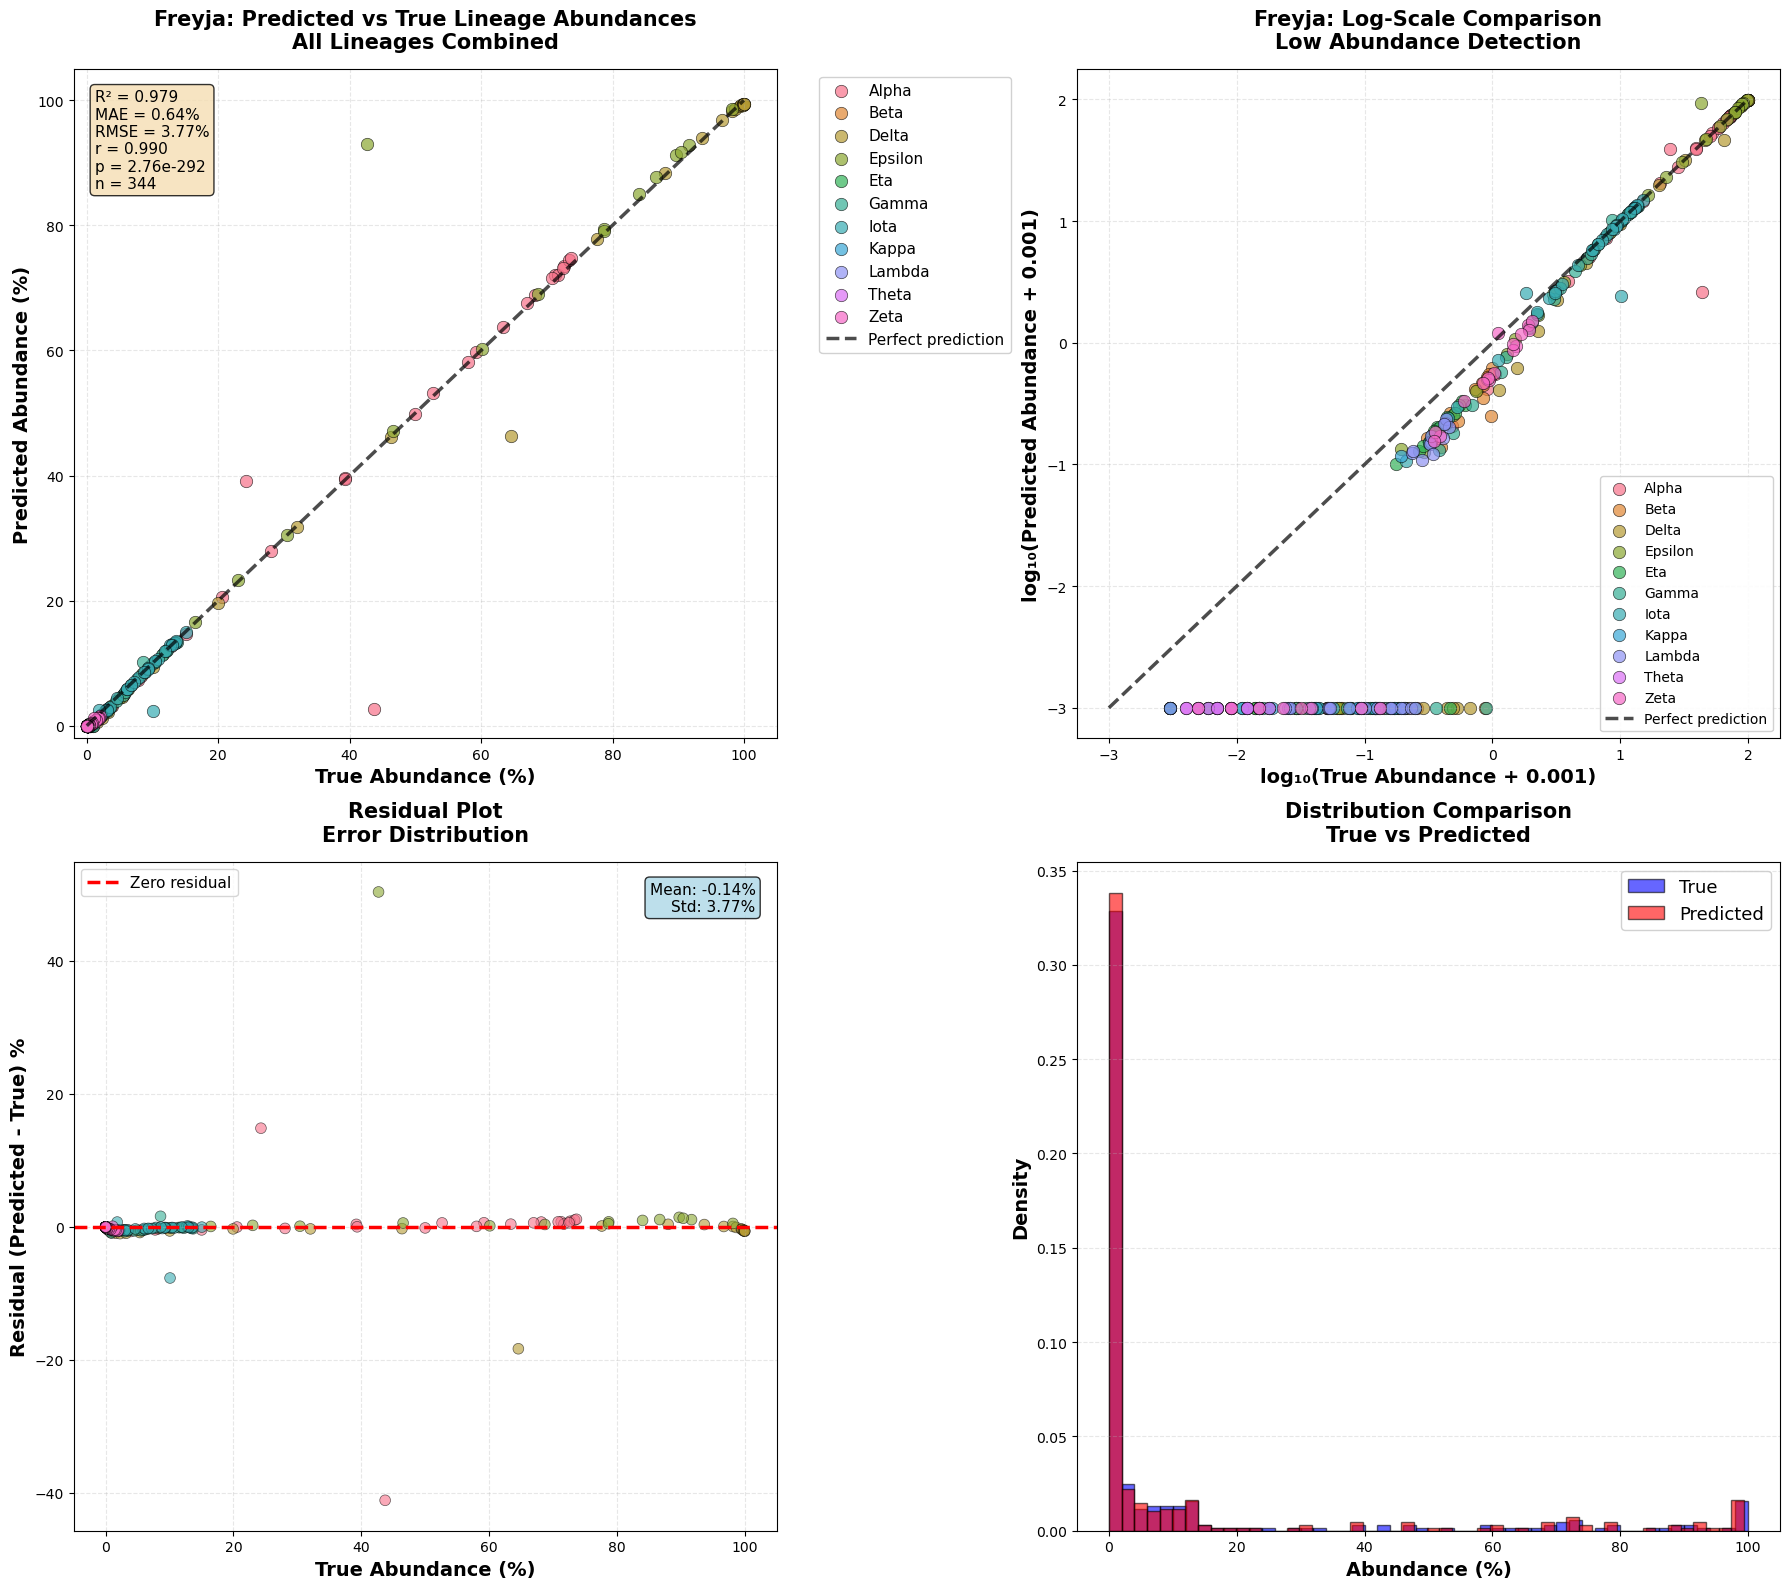

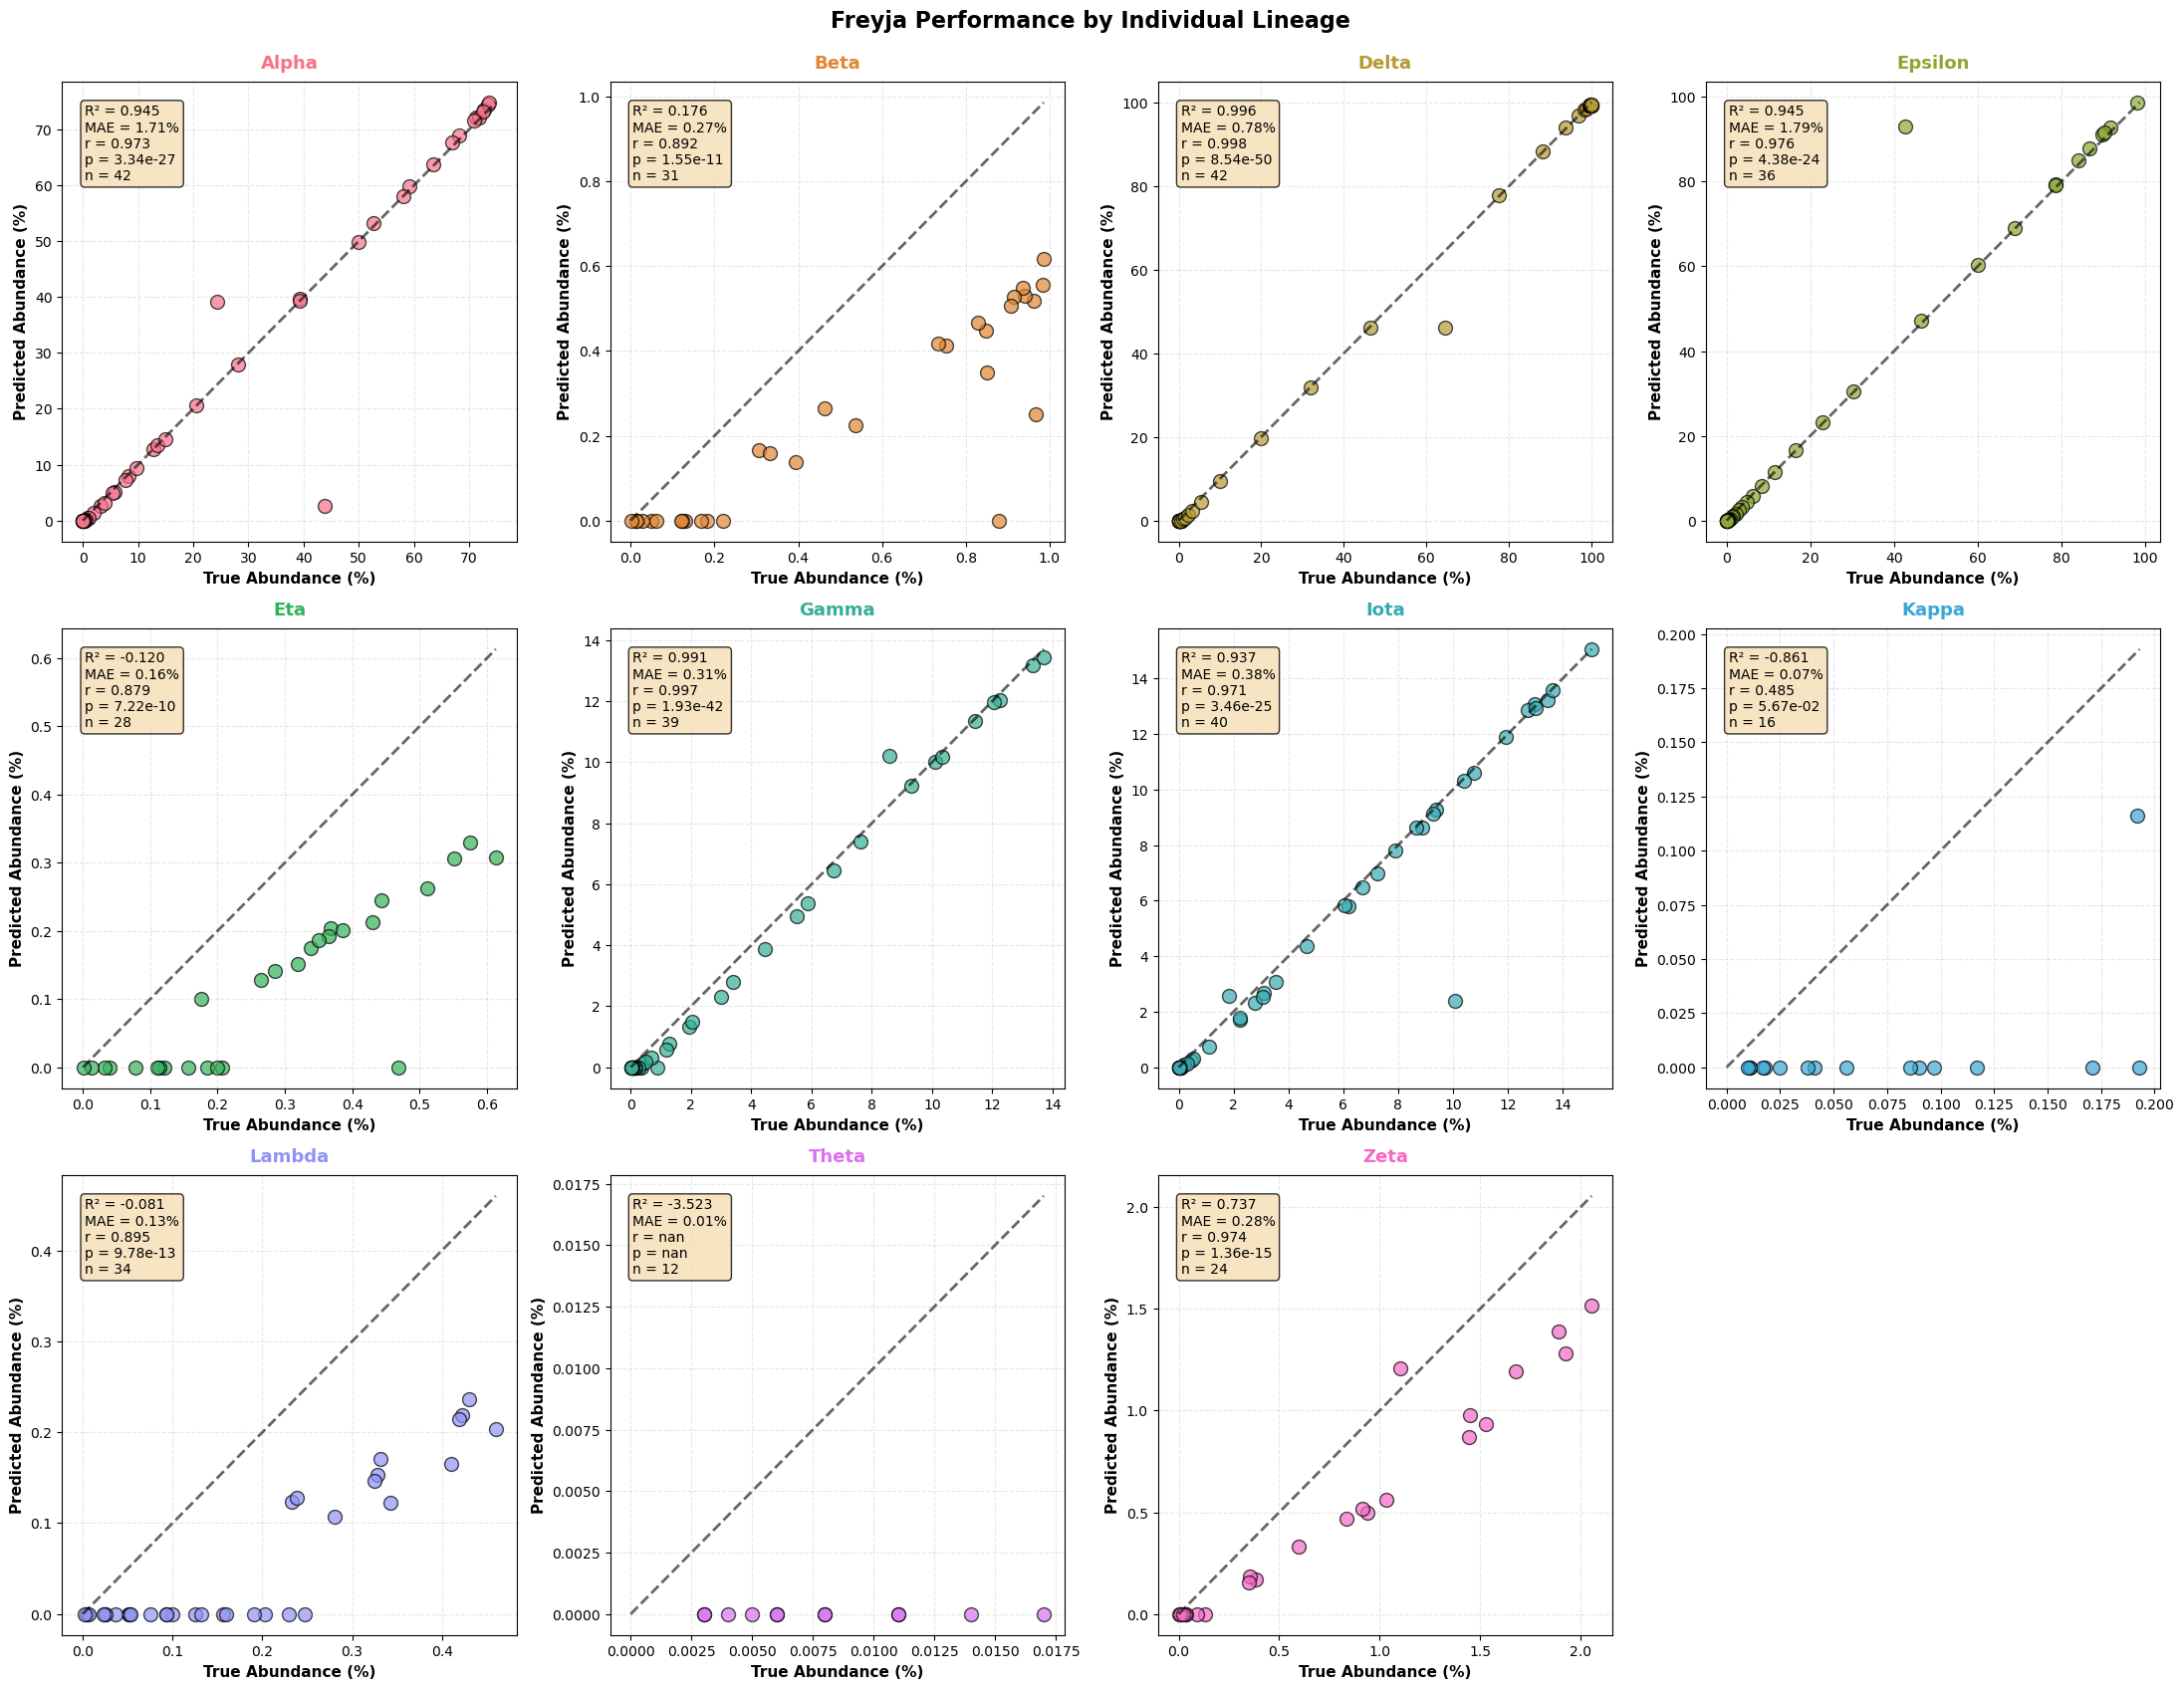

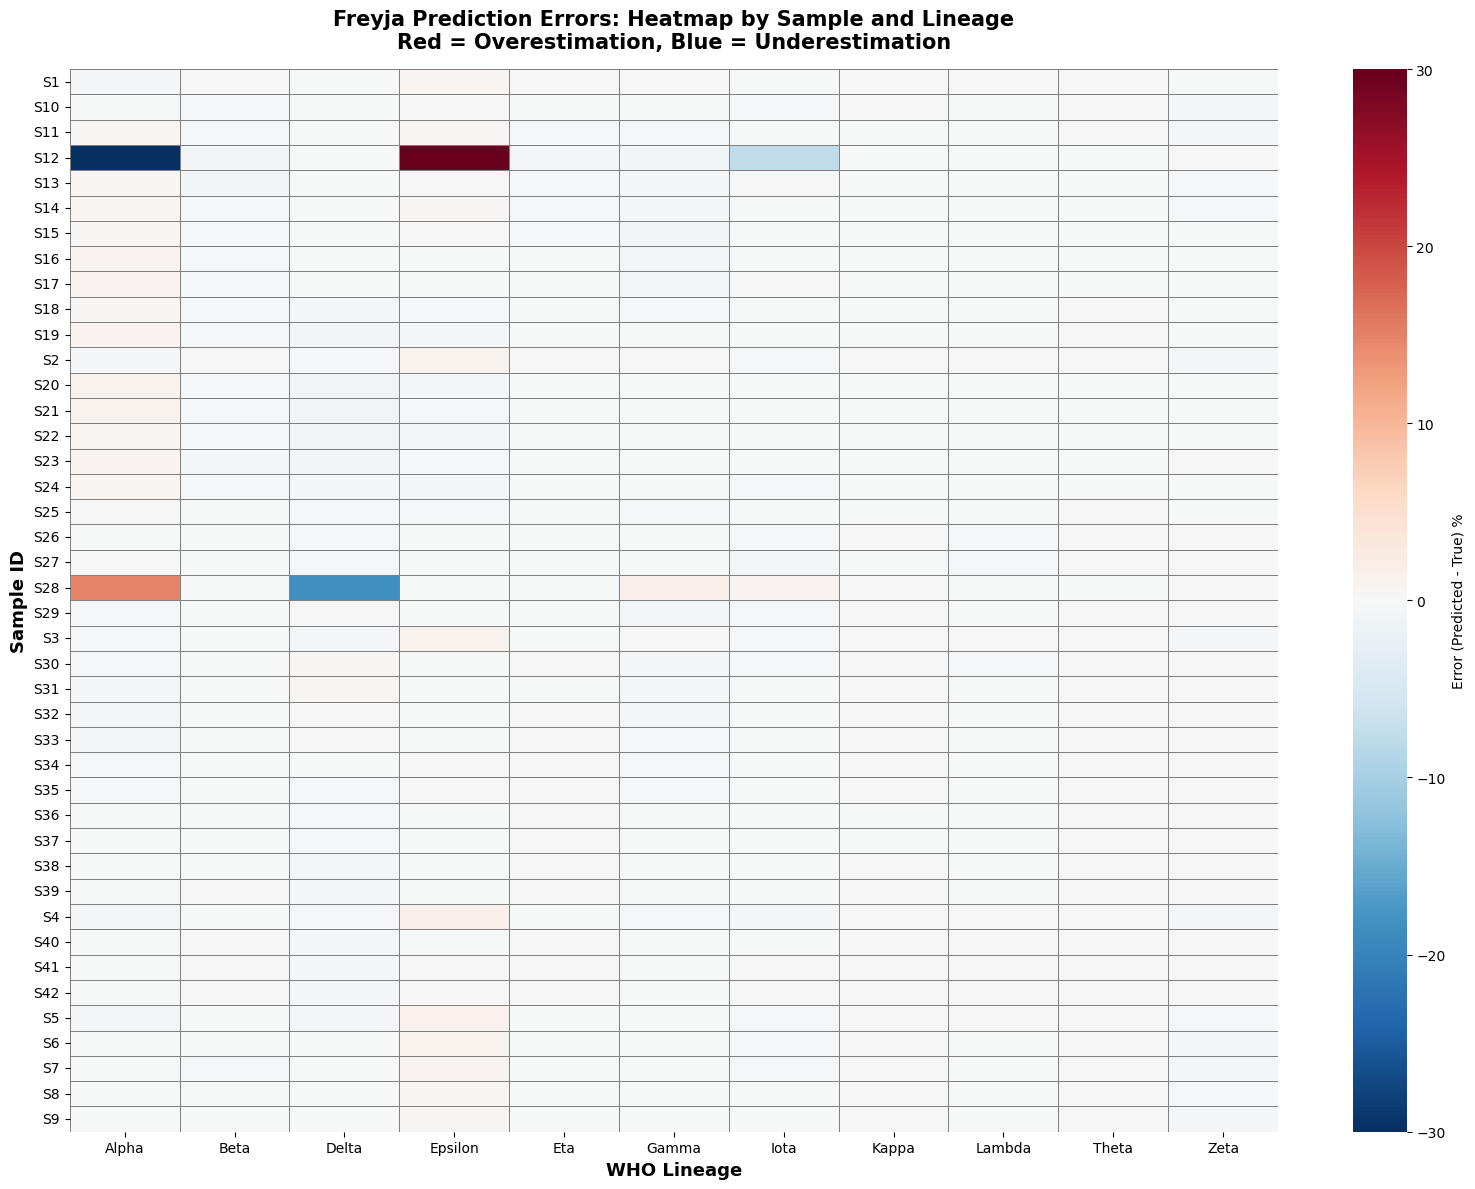

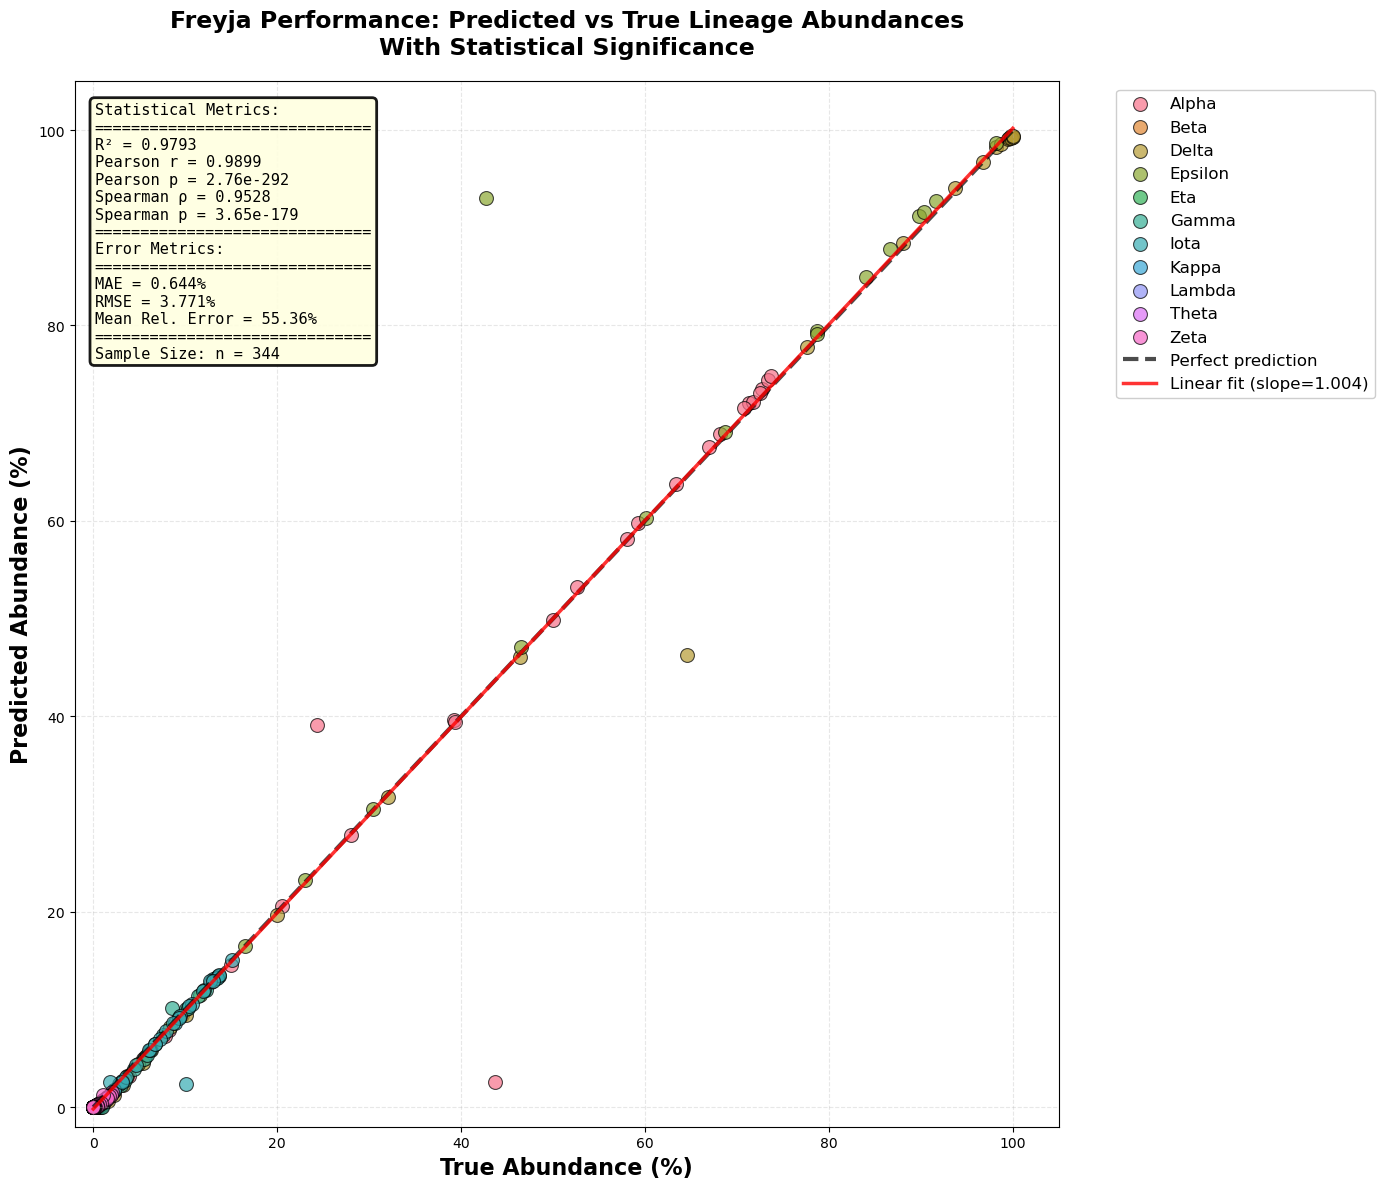

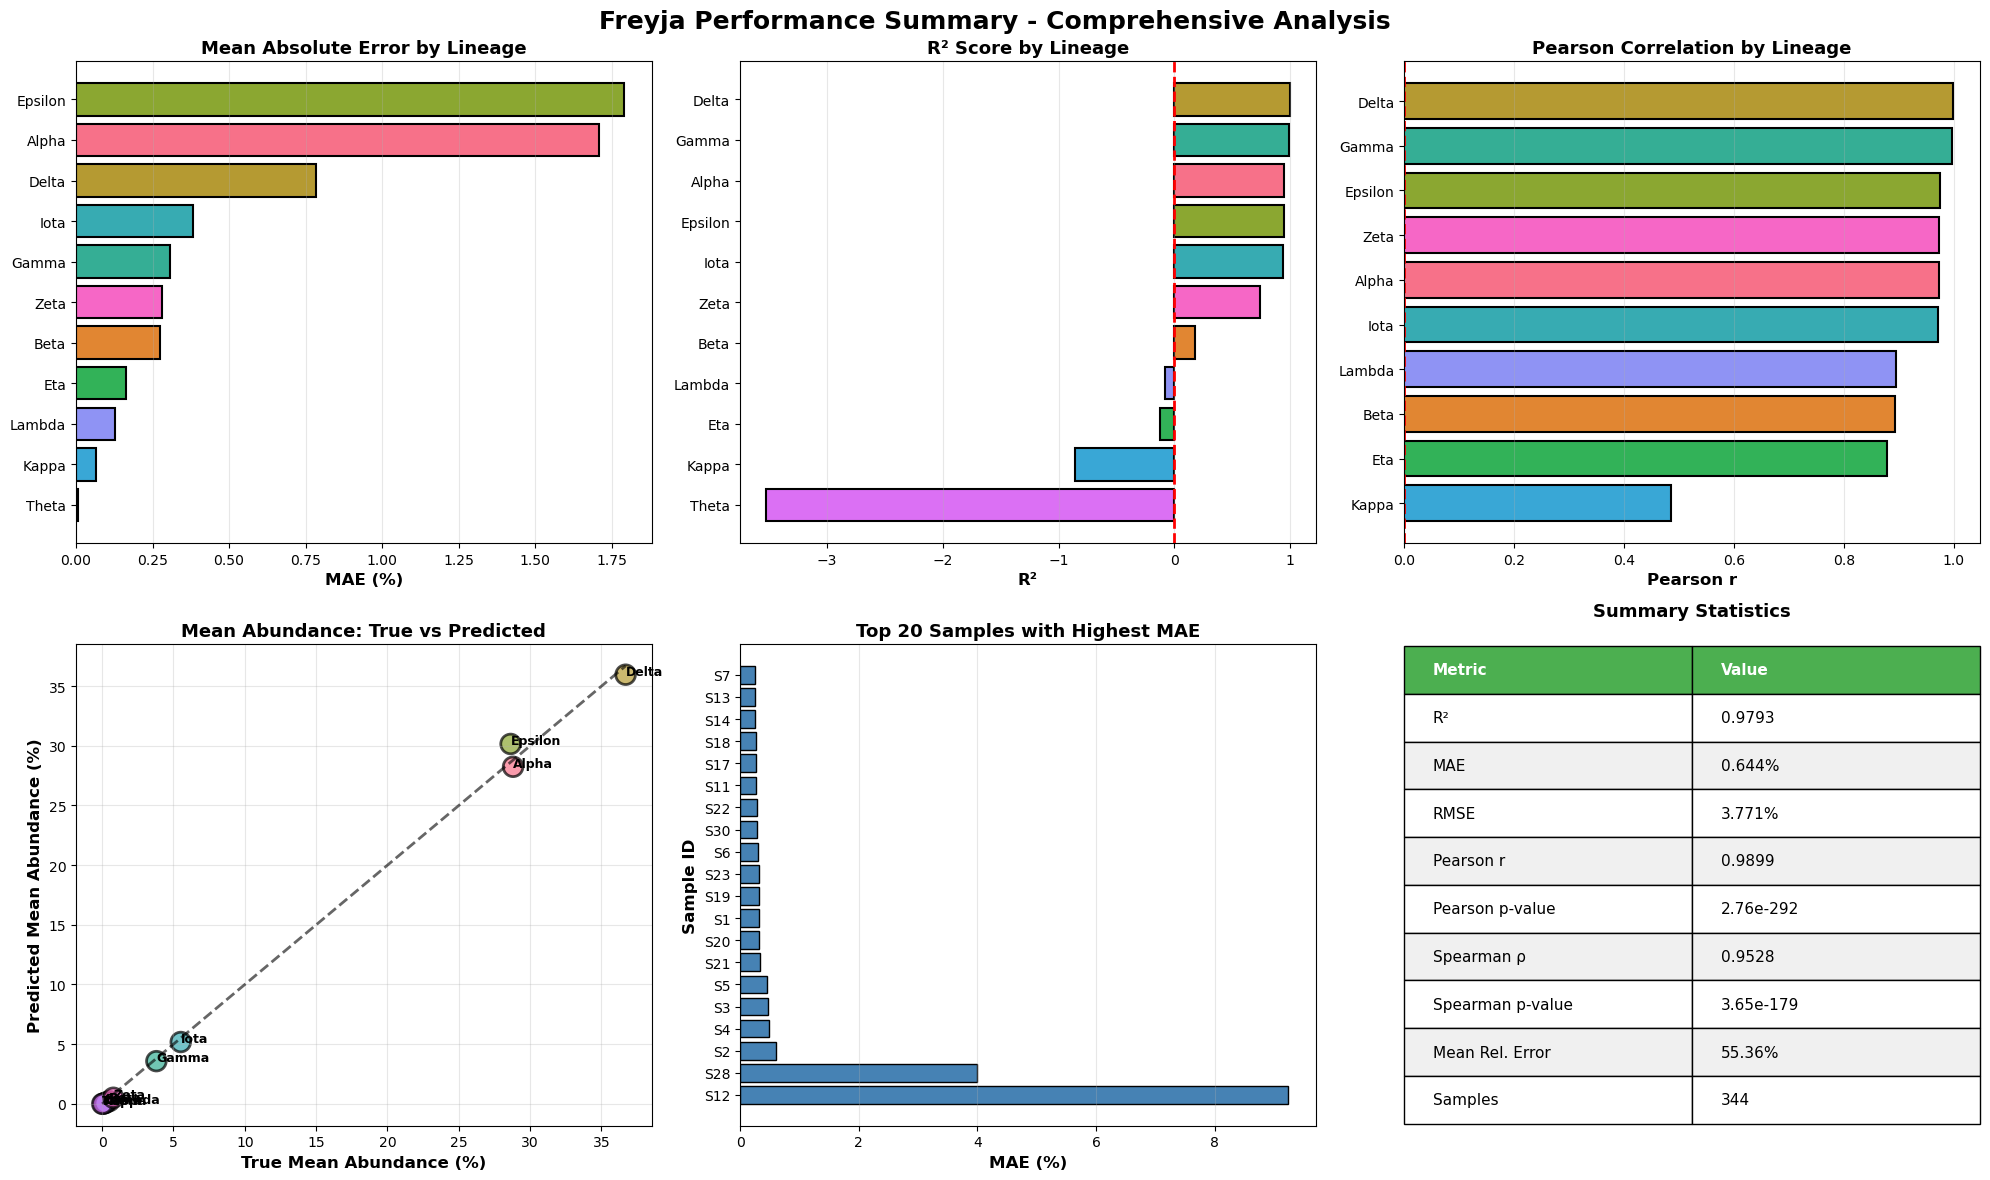

In [ ]:


# ===== 5. СОЗДАНИЕ SCATTER PLOTS =====


# Plot 2: Log scale
ax = axes[0, 1]
for lineage in lineages:
    data = comparison_df_filtered[comparison_df_filtered['Lineage'] == lineage]
    if len(data) > 0:
        # Добавить малое значение чтобы избежать log(0)
        true_log = np.log10(data['True_Abundance'] + 0.001)
        pred_log = np.log10(data['Predicted_Abundance'] + 0.001)
        ax.scatter(true_log, pred_log, alpha=0.7, s=80, 
                  label=lineage, color=lineage_colors[lineage],
                  edgecolors='black', linewidth=0.5)

min_val = -3
max_val = 2
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2.5, 
        label='Perfect prediction', alpha=0.7)

ax.set_xlabel('log₁₀(True Abundance + 0.001)', fontsize=14, fontweight='bold')
ax.set_ylabel('log₁₀(Predicted Abundance + 0.001)', fontsize=14, fontweight='bold')
ax.set_title('Freyja: Log-Scale Comparison\nLow Abundance Detection', 
            fontsize=15, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)

# Plot 3: Residuals
ax = axes[1, 0]
residuals = comparison_df_filtered['Predicted_Abundance'] - comparison_df_filtered['True_Abundance']
colors_residual = [lineage_colors[l] for l in comparison_df_filtered['Lineage']]
ax.scatter(comparison_df_filtered['True_Abundance'], residuals, 
          alpha=0.6, s=60, c=colors_residual, edgecolors='black', linewidth=0.5)
ax.axhline(y=0, color='red', linestyle='--', lw=2.5, label='Zero residual')
ax.set_xlabel('True Abundance (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Residual (Predicted - True) %', fontsize=14, fontweight='bold')
ax.set_title('Residual Plot\nError Distribution', fontsize=15, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

# Добавить статистику residuals
residual_mean = residuals.mean()
residual_std = residuals.std()
textstr = f'Mean: {residual_mean:.2f}%\nStd: {residual_std:.2f}%'
ax.text(0.97, 0.97, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Plot 4: Distribution comparison
ax = axes[1, 1]
ax.hist(comparison_df_filtered['True_Abundance'], bins=50, alpha=0.6, 
       label='True', color='blue', density=True, edgecolor='black')
ax.hist(comparison_df_filtered['Predicted_Abundance'], bins=50, alpha=0.6, 
       label='Predicted', color='red', density=True, edgecolor='black')
ax.set_xlabel('Abundance (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Density', fontsize=14, fontweight='bold')
ax.set_title('Distribution Comparison\nTrue vs Predicted', 
            fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=13, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig('freyja_scatter_plots_comprehensive.png', dpi=300, bbox_inches='tight')
print("\n✅ Сохранено: freyja_scatter_plots_comprehensive.png")

# Figure 2: Scatter plots по отдельным линиям
fig, axes = plt.subplots(3, 4, figsize=(22, 17))
axes = axes.flatten()

for idx, lineage in enumerate(lineages):
    ax = axes[idx]
    data = comparison_df_filtered[comparison_df_filtered['Lineage'] == lineage]
    
    if len(data) > 0:
        ax.scatter(data['True_Abundance'], data['Predicted_Abundance'], 
                  alpha=0.7, s=100, color=lineage_colors[lineage],
                  edgecolors='black', linewidth=1)
        
        # Линия идеального предсказания
        max_val = max(data['True_Abundance'].max(), data['Predicted_Abundance'].max())
        ax.plot([0, max_val], [0, max_val], 'k--', lw=2, alpha=0.6)
        
        # Метрики для этой линии
        if len(data) > 2:
            lineage_r2 = r2_score(data['True_Abundance'], data['Predicted_Abundance'])
            lineage_mae = mean_absolute_error(data['True_Abundance'], data['Predicted_Abundance'])
            lineage_pearson, lineage_p = stats.pearsonr(data['True_Abundance'], data['Predicted_Abundance'])
            
            textstr = (f'R² = {lineage_r2:.3f}\n'
                      f'MAE = {lineage_mae:.2f}%\n'
                      f'r = {lineage_pearson:.3f}\n'
                      f'p = {lineage_p:.2e}\n'
                      f'n = {len(data)}')
            ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                   verticalalignment='top', bbox=dict(boxstyle='round', 
                   facecolor='wheat', alpha=0.8))
    
    ax.set_xlabel('True Abundance (%)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Predicted Abundance (%)', fontsize=11, fontweight='bold')
    ax.set_title(f'{lineage}', fontsize=13, fontweight='bold', 
                pad=10, color=lineage_colors[lineage])
    ax.grid(True, alpha=0.3, linestyle='--')

# Удалить лишний subplot
if len(lineages) < len(axes):
    fig.delaxes(axes[-1])

plt.suptitle('Freyja Performance by Individual Lineage', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('freyja_scatter_by_lineage.png', dpi=300, bbox_inches='tight')
print("✅ Сохранено: freyja_scatter_by_lineage.png")

# Figure 3: Heatmap ошибок
pivot_pred = comparison_df.pivot_table(
    values='Predicted_Abundance', 
    index='Sample', 
    columns='Lineage', 
    aggfunc='first'
).fillna(0)

pivot_true = comparison_df.pivot_table(
    values='True_Abundance', 
    index='Sample', 
    columns='Lineage', 
    aggfunc='first'
).fillna(0)

error_matrix = pivot_pred - pivot_true

plt.figure(figsize=(16, 12))
sns.heatmap(error_matrix, cmap='RdBu_r', center=0, 
           cbar_kws={'label': 'Error (Predicted - True) %'},
           vmin=-30, vmax=30, linewidths=0.5, linecolor='gray')
plt.title('Freyja Prediction Errors: Heatmap by Sample and Lineage\n' + 
         'Red = Overestimation, Blue = Underestimation', 
         fontsize=15, fontweight='bold', pad=15)
plt.xlabel('WHO Lineage', fontsize=13, fontweight='bold')
plt.ylabel('Sample ID', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('freyja_error_heatmap.png', dpi=300, bbox_inches='tight')
print("✅ Сохранено: freyja_error_heatmap.png")

# ===== 6. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ =====

# Сохранить сравнительную таблицу
comparison_df_filtered.to_csv('freyja_comparison_table.csv', index=False)
print("✅ Сохранено: freyja_comparison_table.csv")

# Сохранить summary метрик
summary_metrics = {
    'Metric': ['MAE (%)', 'RMSE (%)', 'R²', 'Pearson r', 'Pearson p-value',
               'Spearman ρ', 'Spearman p-value',
               'Mean Relative Error (%)', 'Median Relative Error (%)', 
               'Total Comparisons', 'Comparisons with True > 0.1%'],
    'Value': [mae, rmse, r2, pearson_r, pearson_p, spearman_r, spearman_p,
             mean_relative_error, median_relative_error, 
             len(comparison_df_filtered), len(nonzero_true)]
}
summary_df = pd.DataFrame(summary_metrics)
summary_df.to_csv('freyja_metrics_summary.csv', index=False)
print("✅ Сохранено: freyja_metrics_summary.csv")

# Создать детальный отчет по каждой линии
lineage_metrics = []
for lineage in lineages:
    lineage_data = comparison_df_filtered[comparison_df_filtered['Lineage'] == lineage]
    if len(lineage_data) > 2:
        lineage_mae = mean_absolute_error(lineage_data['True_Abundance'], 
                                          lineage_data['Predicted_Abundance'])
        lineage_rmse = np.sqrt(mean_squared_error(lineage_data['True_Abundance'], 
                                                   lineage_data['Predicted_Abundance']))
        lineage_r2 = r2_score(lineage_data['True_Abundance'], 
                             lineage_data['Predicted_Abundance'])
        lineage_pearson, lineage_p = stats.pearsonr(lineage_data['True_Abundance'], 
                                                     lineage_data['Predicted_Abundance'])
        
        # Статистика для этой линии
        true_mean = lineage_data['True_Abundance'].mean()
        pred_mean = lineage_data['Predicted_Abundance'].mean()
        true_max = lineage_data['True_Abundance'].max()
        pred_max = lineage_data['Predicted_Abundance'].max()
        
        lineage_metrics.append({
            'Lineage': lineage,
            'n_samples': len(lineage_data),
            'MAE': lineage_mae,
            'RMSE': lineage_rmse,
            'R2': lineage_r2,
            'Pearson_r': lineage_pearson,
            'Pearson_p': lineage_p,
            'True_Mean': true_mean,
            'Pred_Mean': pred_mean,
            'True_Max': true_max,
            'Pred_Max': pred_max
        })

lineage_metrics_df = pd.DataFrame(lineage_metrics)
lineage_metrics_df.to_csv('freyja_lineage_metrics.csv', index=False)
print("✅ Сохранено: freyja_lineage_metrics.csv")

# Создать таблицу ошибок по сэмплам
sample_errors = []
for sample in gt_df['Sample']:
    sample_data = comparison_df_filtered[comparison_df_filtered['Sample'] == sample]
    
    if len(sample_data) > 0:
        sample_mae = mean_absolute_error(sample_data['True_Abundance'], 
                                         sample_data['Predicted_Abundance'])
        sample_rmse = np.sqrt(mean_squared_error(sample_data['True_Abundance'], 
                                                 sample_data['Predicted_Abundance']))
        
        # Найти доминантную линию
        max_true_idx = sample_data['True_Abundance'].idxmax()
        dominant_lineage = sample_data.loc[max_true_idx, 'Lineage']
        dominant_abundance = sample_data.loc[max_true_idx, 'True_Abundance']
        
        sample_errors.append({
            'Sample': sample,
            'MAE': sample_mae,
            'RMSE': sample_rmse,
            'Dominant_Lineage': dominant_lineage,
            'Dominant_Abundance': dominant_abundance
        })

sample_errors_df = pd.DataFrame(sample_errors)
sample_errors_df.to_csv('freyja_sample_errors.csv', index=False)
print("✅ Сохранено: freyja_sample_errors.csv")

print("\n" + "="*70)
print("✅ ВСЕ ГРАФИКИ И ТАБЛИЦЫ СОЗДАНЫ УСПЕШНО!")
print("="*70)

# ===== 7. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ =====

# Вывести примеры сравнений для проверки
print("\n" + "="*70)
print("ПРИМЕРЫ СРАВНЕНИЙ (первые 20 строк):")
print("="*70)
display_df = comparison_df_filtered[['Sample', 'Lineage', 'True_Abundance', 'Predicted_Abundance', 'absolute_error']].head(20)
print(display_df.to_string(index=False))

print("\n" + "="*70)
print("ПРИМЕРЫ НАИБОЛЬШИХ ОШИБОК:")
print("="*70)
worst_errors = comparison_df_filtered.nlargest(10, 'absolute_error')
print(worst_errors[['Sample', 'Lineage', 'True_Abundance', 'Predicted_Abundance', 'absolute_error']].to_string(index=False))

print("\n" + "="*70)
print("СТАТИСТИКА ПО ДИАПАЗОНАМ ABUNDANCE:")
print("="*70)

# Разделить на диапазоны
bins = [0, 0.1, 1, 5, 20, 100]
labels = ['<0.1%', '0.1-1%', '1-5%', '5-20%', '>20%']
comparison_df_filtered['abundance_range'] = pd.cut(comparison_df_filtered['True_Abundance'], 
                                                    bins=bins, labels=labels)

for range_label in labels:
    range_data = comparison_df_filtered[comparison_df_filtered['abundance_range'] == range_label]
    if len(range_data) > 0:
        range_mae = mean_absolute_error(range_data['True_Abundance'], 
                                        range_data['Predicted_Abundance'])
        range_r2 = r2_score(range_data['True_Abundance'], 
                           range_data['Predicted_Abundance']) if len(range_data) > 1 else np.nan
        print(f"{range_label:>10}: n={len(range_data):>4}, MAE={range_mae:>7.3f}%, R²={range_r2:>6.3f}")

print("\n" + "="*70)
print("ФИНАЛЬНАЯ ПРОВЕРКА ДАННЫХ:")
print("="*70)

# Проверить несколько конкретных сэмплов
test_samples = ['S1', 'S10', 'S20', 'S42']
for sample in test_samples:
    print(f"\n{sample}:")
    
    # Ground Truth
    gt_sample_data = gt_df[gt_df['Sample'] == sample]
    if len(gt_sample_data) > 0:
        gt_values = gt_sample_data[lineages].values[0]
        gt_sum = sum(gt_values)
        top_3_true = sorted([(lineages[i], gt_values[i]) for i in range(len(lineages))], 
                           key=lambda x: -x[1])[:3]
        
        print(f"  Ground Truth sum: {gt_sum:.2f}%")
        print(f"  Top 3 True: {[(lin, f'{val:.2f}%') for lin, val in top_3_true]}")
    
    # Freyja
    freyja_sample_data = comparison_df[comparison_df['Sample'] == sample]
    if len(freyja_sample_data) > 0:
        freyja_sum = freyja_sample_data['Predicted_Abundance'].sum()
        freyja_sorted = freyja_sample_data.nlargest(3, 'Predicted_Abundance')
        top_3_pred = [(row['Lineage'], row['Predicted_Abundance']) 
                     for _, row in freyja_sorted.iterrows()]
        
        print(f"  Freyja sum: {freyja_sum:.2f}%")
        print(f"  Top 3 Pred: {[(lin, f'{val:.2f}%') for lin, val in top_3_pred]}")

print("\n" + "="*70)
print("АНАЛИЗ ЗАВЕРШЕН!")
print("="*70)
print("\nСозданные файлы:")
print("  📊 freyja_scatter_plots_comprehensive.png")
print("  📊 freyja_scatter_by_lineage.png")
print("  📊 freyja_error_heatmap.png")
print("  📋 freyja_comparison_table.csv")
print("  📋 freyja_metrics_summary.csv")
print("  📋 freyja_lineage_metrics.csv")
print("  📋 freyja_sample_errors.csv")
print("="*70)

# ===== 8. СОЗДАНИЕ ДОПОЛНИТЕЛЬНОГО ГРАФИКА С R И P VALUES =====

# Figure 4: Scatter plot с аннотациями r и p-value
fig, ax = plt.subplots(figsize=(14, 12))

# Scatter plot
for lineage in lineages:
    data = comparison_df_filtered[comparison_df_filtered['Lineage'] == lineage]
    if len(data) > 0:
        ax.scatter(data['True_Abundance'], data['Predicted_Abundance'], 
                  alpha=0.7, s=100, label=lineage, color=lineage_colors[lineage],
                  edgecolors='black', linewidth=0.8)

# Диагональная линия
max_val = max(comparison_df_filtered['True_Abundance'].max(), 
              comparison_df_filtered['Predicted_Abundance'].max())
ax.plot([0, max_val], [0, max_val], 'k--', lw=3, label='Perfect prediction', alpha=0.7)

# Регрессионная линия
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(
    comparison_df_filtered['True_Abundance'], 
    comparison_df_filtered['Predicted_Abundance']
)
x_line = np.array([0, max_val])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r-', lw=2.5, alpha=0.8, label=f'Linear fit (slope={slope:.3f})')

ax.set_xlabel('True Abundance (%)', fontsize=16, fontweight='bold')
ax.set_ylabel('Predicted Abundance (%)', fontsize=16, fontweight='bold')
ax.set_title('Freyja Performance: Predicted vs True Lineage Abundances\nWith Statistical Significance', 
            fontsize=17, fontweight='bold', pad=20)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(-2, max_val + 5)
ax.set_ylim(-2, max_val + 5)

# Расширенная статистика
textstr = (f'Statistical Metrics:\n'
          f'{"="*30}\n'
          f'R² = {r2:.4f}\n'
          f'Pearson r = {pearson_r:.4f}\n'
          f'Pearson p = {pearson_p:.2e}\n'
          f'Spearman ρ = {spearman_r:.4f}\n'
          f'Spearman p = {spearman_p:.2e}\n'
          f'{"="*30}\n'
          f'Error Metrics:\n'
          f'{"="*30}\n'
          f'MAE = {mae:.3f}%\n'
          f'RMSE = {rmse:.3f}%\n'
          f'Mean Rel. Error = {mean_relative_error:.2f}%\n'
          f'{"="*30}\n'
          f'Sample Size: n = {len(comparison_df_filtered)}')

ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', 
        facecolor='lightyellow', alpha=0.9, edgecolor='black', linewidth=2),
        family='monospace')

plt.tight_layout()
plt.savefig('freyja_scatter_with_stats.png', dpi=300, bbox_inches='tight')
print("✅ Сохранено: freyja_scatter_with_stats.png")

# ===== 9. СОЗДАНИЕ ФИНАЛЬНОГО SUMMARY PLOT =====

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Plot 1: MAE по линиям
ax = axes[0, 0]
lineage_metrics_df_sorted = lineage_metrics_df.sort_values('MAE', ascending=True)
colors_bar = [lineage_colors[lin] for lin in lineage_metrics_df_sorted['Lineage']]
ax.barh(lineage_metrics_df_sorted['Lineage'], lineage_metrics_df_sorted['MAE'], 
        color=colors_bar, edgecolor='black', linewidth=1.5)
ax.set_xlabel('MAE (%)', fontsize=12, fontweight='bold')
ax.set_title('Mean Absolute Error by Lineage', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Plot 2: R² по линиям
ax = axes[0, 1]
lineage_metrics_df_sorted_r2 = lineage_metrics_df.sort_values('R2', ascending=True)
colors_bar = [lineage_colors[lin] for lin in lineage_metrics_df_sorted_r2['Lineage']]
ax.barh(lineage_metrics_df_sorted_r2['Lineage'], lineage_metrics_df_sorted_r2['R2'], 
        color=colors_bar, edgecolor='black', linewidth=1.5)
ax.set_xlabel('R²', fontsize=12, fontweight='bold')
ax.set_title('R² Score by Lineage', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)

# Plot 3: Pearson r по линиям
ax = axes[0, 2]
lineage_metrics_df_sorted_r = lineage_metrics_df.sort_values('Pearson_r', ascending=True)
colors_bar = [lineage_colors[lin] for lin in lineage_metrics_df_sorted_r['Lineage']]
ax.barh(lineage_metrics_df_sorted_r['Lineage'], lineage_metrics_df_sorted_r['Pearson_r'], 
        color=colors_bar, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Pearson r', fontsize=12, fontweight='bold')
ax.set_title('Pearson Correlation by Lineage', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)

# Plot 4: True Mean vs Pred Mean
ax = axes[1, 0]
ax.scatter(lineage_metrics_df['True_Mean'], lineage_metrics_df['Pred_Mean'],
          s=200, alpha=0.7, edgecolors='black', linewidth=2,
          c=[lineage_colors[lin] for lin in lineage_metrics_df['Lineage']])
for idx, row in lineage_metrics_df.iterrows():
    ax.annotate(row['Lineage'], (row['True_Mean'], row['Pred_Mean']),
               fontsize=9, fontweight='bold')
max_val = max(lineage_metrics_df['True_Mean'].max(), lineage_metrics_df['Pred_Mean'].max())
ax.plot([0, max_val], [0, max_val], 'k--', lw=2, alpha=0.6)
ax.set_xlabel('True Mean Abundance (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Mean Abundance (%)', fontsize=12, fontweight='bold')
ax.set_title('Mean Abundance: True vs Predicted', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 5: MAE по сэмплам
ax = axes[1, 1]
sample_errors_df_sorted = sample_errors_df.sort_values('MAE', ascending=False).head(20)
ax.barh(sample_errors_df_sorted['Sample'], sample_errors_df_sorted['MAE'],
       color='steelblue', edgecolor='black', linewidth=1)
ax.set_xlabel('MAE (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sample ID', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Samples with Highest MAE', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Plot 6: Summary statistics table
ax = axes[1, 2]
ax.axis('tight')
ax.axis('off')

summary_table_data = [
    ['Metric', 'Value'],
    ['R²', f'{r2:.4f}'],
    ['MAE', f'{mae:.3f}%'],
    ['RMSE', f'{rmse:.3f}%'],
    ['Pearson r', f'{pearson_r:.4f}'],
    ['Pearson p-value', f'{pearson_p:.2e}'],
    ['Spearman ρ', f'{spearman_r:.4f}'],
    ['Spearman p-value', f'{spearman_p:.2e}'],
    ['Mean Rel. Error', f'{mean_relative_error:.2f}%'],
    ['Samples', f'{len(comparison_df_filtered)}']
]

table = ax.table(cellText=summary_table_data, cellLoc='left',
                loc='center', colWidths=[0.5, 0.5])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Стиль заголовка
for i in range(2):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Чередующиеся цвета строк
for i in range(1, len(summary_table_data)):
    for j in range(2):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')

ax.set_title('Summary Statistics', fontsize=13, fontweight='bold', pad=20)

plt.suptitle('Freyja Performance Summary - Comprehensive Analysis', 
            fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('freyja_performance_summary.png', dpi=300, bbox_inches='tight')
print("✅ Сохранено: freyja_performance_summary.png")

print("\n" + "="*70)
print("🎉 ВСЕ АНАЛИЗЫ И ВИЗУАЛИЗАЦИИ ЗАВЕРШЕНЫ!")
print("="*70)
print("\nИтоговый список файлов:")
print("  📊 freyja_scatter_plots_comprehensive.png")
print("  📊 freyja_scatter_by_lineage.png")
print("  📊 freyja_error_heatmap.png")
print("  📊 freyja_scatter_with_stats.png")
print("  📊 freyja_performance_summary.png")
print("  📋 freyja_comparison_table.csv")
print("  📋 freyja_metrics_summary.csv")
print("  📋 freyja_lineage_metrics.csv")
print("  📋 freyja_sample_errors.csv")
print("="*70)